# Hito 2 Modeling — F1 Race Strategy Advisor

This notebook extends Hito 1 by modeling two targets: `is_top10` and `is_top5`. The target pair supports the strategy question by separating points-finish security from stronger upside.

## Load data and define modeling choices

This cell loads the race-level dataset and records the locked choices for Hito 2. The model uses the same temporal split as Hito 1: 2019-2021 for training, 2022 for calibration, and 2023-2024 for final testing after the model is locked. The conservative feature set combines pre-race context with strategy variables used as user-controlled scenario inputs. This cell deliberately does not evaluate on the test set or use test outcomes for feature selection.

In [12]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_SEED = 414
DATA_PATH = "../data/f1_strategy_race_level.csv"

df = pd.read_csv(DATA_PATH)

targets = ["is_top10", "is_top5"]

numeric_features = [
    "grid_position",
    "driver_prior3_avg_finish",
    "constructor_prior3_avg_finish",
    "driver_circuit_prior_avg",
    "n_stops",
]

categorical_features = [
    "constructor_tier",
    "circuit_type",
    "strategy_type",
    "compound_sequence",
]

model_features = numeric_features + categorical_features

train_df = df[df["season"].between(2019, 2021)].copy()
calibration_df = df[df["season"].eq(2022)].copy()
test_df = df[df["season"].between(2023, 2024)].copy()

split_summary = pd.DataFrame({
    "split": ["train", "calibration", "test"],
    "seasons": ["2019-2021", "2022", "2023-2024"],
    "rows": [len(train_df), len(calibration_df), len(test_df)],
})

feature_audit = pd.DataFrame({
    "feature": model_features,
    "role": [
        "pre-race",
        "pre-race",
        "pre-race",
        "pre-race",
        "scenario input",
        "pre-race",
        "pre-race",
        "scenario input",
        "scenario input",
    ],
})

display(split_summary)
display(feature_audit)


,split,seasons,rows
0,train,2019-2021,1132
1,calibration,2022,426
2,test,2023-2024,889


,feature,role
0,grid_position,pre-race
1,driver_prior3_avg_finish,pre-race
2,constructor_prior3_avg_finish,pre-race
3,driver_circuit_prior_avg,pre-race
4,n_stops,scenario input
5,constructor_tier,pre-race
6,circuit_type,pre-race
7,strategy_type,scenario input
8,compound_sequence,scenario input


## Build the shared preprocessing pipeline

This cell defines one preprocessing pipeline that will be reused for both targets. Numeric features are imputed and scaled, while categorical features are imputed and one-hot encoded so logistic regression can use them. Reusing the same preprocessing across targets makes the comparison fair and reproducible. The preprocessing is fitted only inside the training pipeline, so it does not learn category structure or scaling parameters from the test set.

In [13]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features),
])

base_model = LogisticRegression(
    random_state=RANDOM_SEED,
    max_iter=1000,
)

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", base_model),
])

model_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

## Train and calibrate one model per target

This cell trains a separate logistic-regression model for `is_top10` and `is_top5`, then fits a sigmoid calibration mapping on the 2022 calibration block. The calibration step uses each model's raw probability as the single input to a second logistic regression, which keeps the calibration method simple and consistent with Hito 1. This supports the Hito 2 model-comparison requirement because both targets use the same split, feature set, and model family. The cell deliberately stores the trained artifacts without evaluating final 2023-2024 test metrics; that happens only after the models are locked.

In [14]:
trained_models = {}
calibration_summaries = []

for target in targets:
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)),
    ])

    pipeline.fit(train_df[model_features], train_df[target])

    calibration_raw_proba = pipeline.predict_proba(calibration_df[model_features])[:, 1]
    calibrator = LogisticRegression(random_state=RANDOM_SEED)
    calibrator.fit(calibration_raw_proba.reshape(-1, 1), calibration_df[target])

    train_raw_proba = pipeline.predict_proba(train_df[model_features])[:, 1]
    train_calibrated_proba = calibrator.predict_proba(train_raw_proba.reshape(-1, 1))[:, 1]
    calibration_calibrated_proba = calibrator.predict_proba(calibration_raw_proba.reshape(-1, 1))[:, 1]

    trained_models[target] = {
        "pipeline": pipeline,
        "calibrator": calibrator,
    }

    calibration_summaries.append({
        "target": target,
        "train_actual_rate": train_df[target].mean(),
        "train_mean_calibrated_probability": train_calibrated_proba.mean(),
        "calibration_actual_rate": calibration_df[target].mean(),
        "calibration_mean_calibrated_probability": calibration_calibrated_proba.mean(),
    })

calibration_summary = pd.DataFrame(calibration_summaries)
calibration_summary


,target,train_actual_rate,train_mean_calibrated_probability,calibration_actual_rate,calibration_mean_calibrated_probability
0,is_top10,0.515018,0.551011,0.516432,0.516341
1,is_top5,0.256184,0.275290,0.258216,0.258226


## Scenario prediction helper

This cell defines a helper for predicting calibrated probabilities for proposed strategy scenarios. It is needed because Hito 2 must compare scenarios and show where `is_top10` and `is_top5` add different decision value. The helper expects concrete feature values, including strategy inputs, and returns one calibrated probability per target. It deliberately does not search the test set or choose a final disagreement scenario automatically; that choice will be made later after candidate outputs are reviewed.

In [15]:
def predict_strategy_scenarios(scenarios):
    scenario_df = pd.DataFrame(scenarios).copy()
    results = scenario_df.copy()

    for target, artifacts in trained_models.items():
        raw_proba = artifacts["pipeline"].predict_proba(scenario_df[model_features])[:, 1]
        calibrated_proba = artifacts["calibrator"].predict_proba(raw_proba.reshape(-1, 1))[:, 1]
        results[f"predicted_{target}_probability"] = calibrated_proba

    return results

example_scenarios = [
    {
        "scenario": "A_one_stop",
        "grid_position": 4.0,
        "driver_prior3_avg_finish": 5.0,
        "constructor_prior3_avg_finish": 5.0,
        "driver_circuit_prior_avg": 10.5,
        "constructor_tier": "midfield",
        "circuit_type": "permanent",
        "n_stops": 1,
        "strategy_type": "one_stop",
        "compound_sequence": "M-H",
    },
    {
        "scenario": "B_two_stop",
        "grid_position": 4.0,
        "driver_prior3_avg_finish": 5.0,
        "constructor_prior3_avg_finish": 5.0,
        "driver_circuit_prior_avg": 10.5,
        "constructor_tier": "midfield",
        "circuit_type": "permanent",
        "n_stops": 2,
        "strategy_type": "two_stop",
        "compound_sequence": "M-H-S",
    },
]

predict_strategy_scenarios(example_scenarios)


,scenario,grid_position,driver_prior3_avg_finish,constructor_prior3_avg_finish,driver_circuit_prior_avg,constructor_tier,circuit_type,n_stops,strategy_type,compound_sequence,predicted_is_top10_probability,predicted_is_top5_probability
0,A_one_stop,4.0,5.0,5.0,10.5,midfield,permanent,1,one_stop,M-H,0.892756,0.788785
1,B_two_stop,4.0,5.0,5.0,10.5,midfield,permanent,2,two_stop,M-H-S,0.866485,0.811390


## Final locked model comparison

This cell evaluates the locked Hito 2 models on the 2023-2024 test seasons. The model family, features, and calibration method were fixed before this cell, so these results are final evaluation evidence and not tuning feedback. For both `is_top10` and `is_top5`, the table reports a simple target-rate baseline and the calibrated logistic-regression model using Brier score, log loss, and ROC-AUC. The cell deliberately does not change modeling choices after seeing the test metrics.

In [16]:
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score

comparison_rows = []
test_predictions = test_df.copy()

for target in targets:
    y_test = test_df[target]

    baseline_probability = train_df[target].mean()
    baseline_proba = np.repeat(baseline_probability, len(test_df))

    raw_model_proba = trained_models[target]["pipeline"].predict_proba(test_df[model_features])[:, 1]
    model_proba = trained_models[target]["calibrator"].predict_proba(raw_model_proba.reshape(-1, 1))[:, 1]
    test_predictions[f"predicted_{target}_probability"] = model_proba

    comparison_rows.append({
        "target": target,
        "approach": "target_rate_baseline",
        "brier_score": brier_score_loss(y_test, baseline_proba),
        "log_loss": log_loss(y_test, baseline_proba),
        "roc_auc": 0.5,
    })

    comparison_rows.append({
        "target": target,
        "approach": "logistic_regression_calibrated",
        "brier_score": brier_score_loss(y_test, model_proba),
        "log_loss": log_loss(y_test, model_proba),
        "roc_auc": roc_auc_score(y_test, model_proba),
    })

model_comparison = pd.DataFrame(comparison_rows)
model_comparison 


,target,approach,brier_score,log_loss,roc_auc
0,is_top10,target_rate_baseline,0.249702,0.692551,0.500000
1,is_top10,logistic_regression_calibrated,0.139039,0.443436,0.881266
2,is_top5,target_rate_baseline,0.191789,0.571728,0.500000
3,is_top5,logistic_regression_calibrated,0.090479,0.305743,0.934413


## Error-analysis slices

This cell computes error-analysis tables for the required Hito 2 slices: strategy type, circuit type, and constructor tier. For each target and slice value, it reports sample size, actual outcome rate, mean predicted probability, slice Brier score, and mean absolute probability error. Brier score aligns with the primary probability-quality metric, while absolute error is easier to interpret in plain English. The cell uses the locked test predictions and does not retune the model based on weak slices.

In [17]:
slice_columns = ["strategy_type", "circuit_type", "constructor_tier"]
error_slice_tables = {}

for target in targets:
    prediction_col = f"predicted_{target}_probability"
    target_error_df = test_predictions.copy()
    target_error_df["squared_probability_error"] = (
        target_error_df[target] - target_error_df[prediction_col]
    ) ** 2
    target_error_df["absolute_probability_error"] = (
        target_error_df[target] - target_error_df[prediction_col]
    ).abs()

    for slice_column in slice_columns:
        table = (
            target_error_df
            .groupby(slice_column, dropna=False)
            .agg(
                rows=(target, "size"),
                actual_rate=(target, "mean"),
                mean_predicted_probability=(prediction_col, "mean"),
                slice_brier_score=("squared_probability_error", "mean"),
                mean_absolute_probability_error=("absolute_probability_error", "mean"),
            )
            .reset_index()
            .sort_values(["slice_brier_score", "rows"], ascending=[False, False])
        )
        error_slice_tables[(target, slice_column)] = table

for key, table in error_slice_tables.items():
    target, slice_column = key
    print(f"\nTarget: {target} | Slice: {slice_column}")
    display(table)



Target: is_top10 | Slice: strategy_type


,strategy_type,rows,actual_rate,mean_predicted_probability,slice_brier_score,mean_absolute_probability_error
2,three_plus_stop,153,0.405229,0.482190,0.157422,0.326359
1,one_stop,353,0.560907,0.579692,0.147379,0.314466
3,two_stop,368,0.543478,0.516402,0.128149,0.296612
0,no_stop,15,0.000000,0.145318,0.022442,0.145318



Target: is_top10 | Slice: circuit_type


,circuit_type,rows,actual_rate,mean_predicted_probability,slice_brier_score,mean_absolute_probability_error
1,semi-street,118,0.508475,0.517835,0.170578,0.338706
0,permanent,579,0.518135,0.528515,0.135177,0.302941
2,street,192,0.520833,0.539100,0.131304,0.296365



Target: is_top10 | Slice: constructor_tier


,constructor_tier,rows,actual_rate,mean_predicted_probability,slice_brier_score,mean_absolute_probability_error
2,midfield,407,0.619165,0.625381,0.158903,0.336403
0,backmarker,312,0.189103,0.249073,0.131932,0.305326
1,front,170,0.876471,0.814005,0.104528,0.235851



Target: is_top5 | Slice: strategy_type


,strategy_type,rows,actual_rate,mean_predicted_probability,slice_brier_score,mean_absolute_probability_error
2,three_plus_stop,153,0.196078,0.225143,0.102905,0.217876
1,one_stop,353,0.283286,0.314413,0.096733,0.224346
3,two_stop,368,0.271739,0.280912,0.082512,0.202963
0,no_stop,15,0.000000,0.088148,0.011990,0.088148



Target: is_top5 | Slice: circuit_type


,circuit_type,rows,actual_rate,mean_predicted_probability,slice_brier_score,mean_absolute_probability_error
2,street,192,0.260417,0.282599,0.099396,0.224219
0,permanent,579,0.259067,0.280198,0.092797,0.213353
1,semi-street,118,0.254237,0.285074,0.064593,0.186106



Target: is_top5 | Slice: constructor_tier


,constructor_tier,rows,actual_rate,mean_predicted_probability,slice_brier_score,mean_absolute_probability_error
1,front,170,0.676471,0.645535,0.180871,0.346881
2,midfield,407,0.277641,0.287480,0.113530,0.256717
0,backmarker,312,0.006410,0.074959,0.011157,0.080412


## Graphs

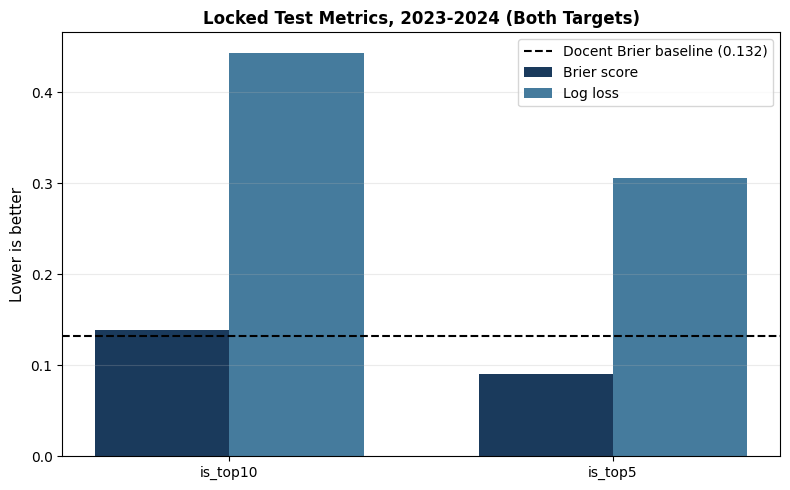

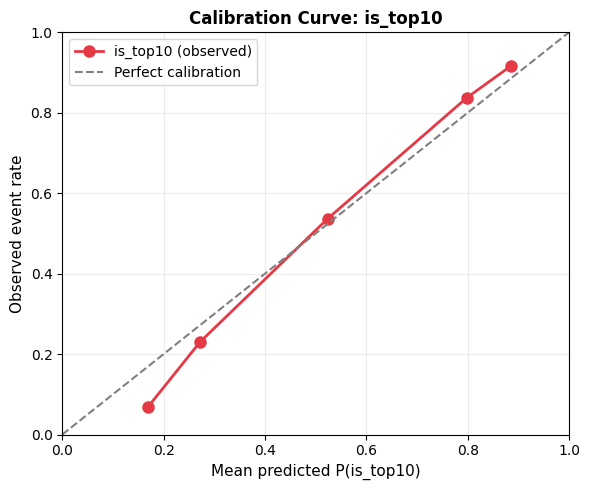

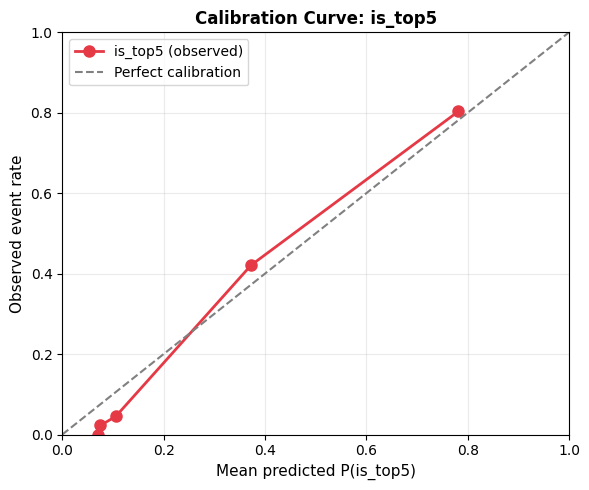

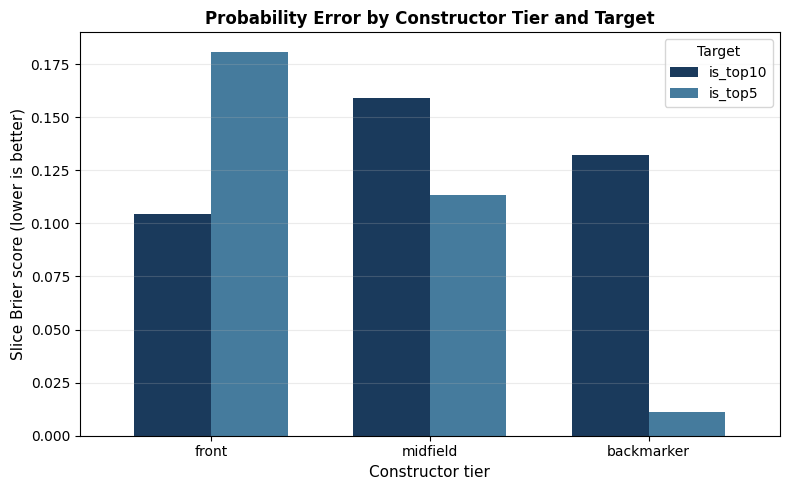

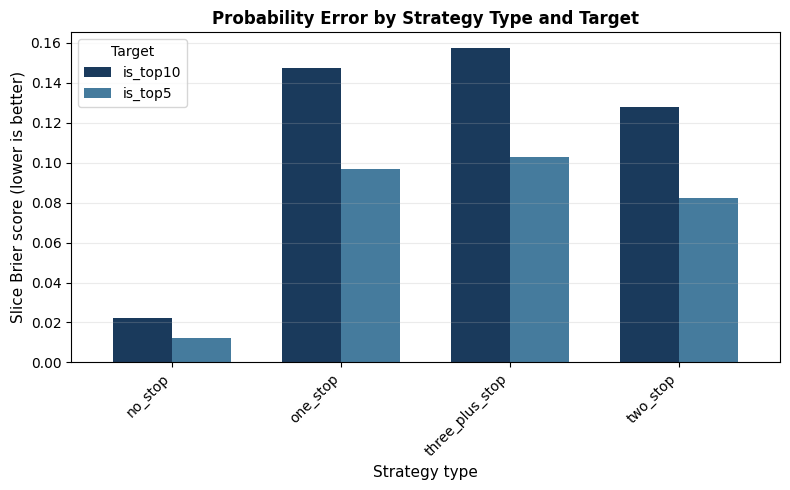

✓ All plots generated successfully.


In [18]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# ===== Plot 1: Metric Summary (Brier and Log Loss vs Docent Baseline) =====

fig, ax = plt.subplots(figsize=(8, 5))
model_rows = model_comparison[model_comparison["approach"] == "logistic_regression_calibrated"]
x = np.arange(len(model_rows))
width = 0.35

ax.bar(x - width/2, model_rows["brier_score"], width, label="Brier score", color="#1A3A5C")
ax.bar(x + width/2, model_rows["log_loss"], width, label="Log loss", color="#457B9D")
ax.axhline(0.132, color="black", linestyle="--", linewidth=1.5, label="Docent Brier baseline (0.132)")
ax.set_xticks(x)
ax.set_xticklabels(model_rows["target"])
ax.set_ylabel("Lower is better", fontsize=11)
ax.set_title("Locked Test Metrics, 2023-2024 (Both Targets)", fontsize=12, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

# ===== Plot 2: Calibration Curves for Both Targets =====

for target in targets:
    pred_col = f"predicted_{target}_probability"
    y_test = test_df[target]
    y_pred = test_predictions[pred_col]
    
    frac_pos, mean_pred = calibration_curve(
        y_test,
        y_pred,
        n_bins=5,
        strategy="quantile",
    )
    
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(mean_pred, frac_pos, marker="o", markersize=8, label=f"{target} (observed)", linewidth=2, color="#E63946")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.5, label="Perfect calibration")
    ax.set_xlabel(f"Mean predicted P({target})", fontsize=11)
    ax.set_ylabel("Observed event rate", fontsize=11)
    ax.set_title(f"Calibration Curve: {target}", fontsize=12, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=10)
    fig.tight_layout()
    plt.show()

# ===== Plot 3: Constructor Tier Slice Comparison =====

constructor_error_data = []
for target in targets:
    constructor_table = error_slice_tables[(target, "constructor_tier")]
    for _, row in constructor_table.iterrows():
        constructor_error_data.append({
            "target": target,
            "constructor_tier": row["constructor_tier"],
            "slice_brier_score": row["slice_brier_score"],
        })

constructor_error_df = pd.DataFrame(constructor_error_data)
pivot = constructor_error_df.pivot(
    index="constructor_tier", columns="target", values="slice_brier_score"
)

# Reorder rows
tier_order = ["front", "midfield", "backmarker"]
pivot = pivot.reindex([t for t in tier_order if t in pivot.index])

fig, ax = plt.subplots(figsize=(8, 5))
pivot.plot(kind="bar", ax=ax, color=["#1A3A5C", "#457B9D"], width=0.7)
ax.set_xlabel("Constructor tier", fontsize=11)
ax.set_ylabel("Slice Brier score (lower is better)", fontsize=11)
ax.set_title("Probability Error by Constructor Tier and Target", fontsize=12, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Target", fontsize=10)
fig.tight_layout()
plt.show()

# ===== Plot 4: Strategy Type Slice Comparison =====

strategy_error_data = []
for target in targets:
    strategy_table = error_slice_tables[(target, "strategy_type")]
    for _, row in strategy_table.iterrows():
        strategy_error_data.append({
            "target": target,
            "strategy_type": row["strategy_type"],
            "slice_brier_score": row["slice_brier_score"],
        })

strategy_error_df = pd.DataFrame(strategy_error_data)
pivot_strategy = strategy_error_df.pivot(
    index="strategy_type", columns="target", values="slice_brier_score"
)

fig, ax = plt.subplots(figsize=(8, 5))
pivot_strategy.plot(kind="bar", ax=ax, color=["#1A3A5C", "#457B9D"], width=0.7)
ax.set_xlabel("Strategy type", fontsize=11)
ax.set_ylabel("Slice Brier score (lower is better)", fontsize=11)
ax.set_title("Probability Error by Strategy Type and Target", fontsize=12, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Target", fontsize=10)
fig.tight_layout()
plt.show()

print("✓ All plots generated successfully.")